In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## Load Data

In [2]:
try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# load f4 
function_folder = os.path.join(base_dir, "function_4")
inputs = np.load(os.path.join(function_folder, "initial_inputs.npy"))
outputs = np.load(os.path.join(function_folder, "initial_outputs.npy"))

# reshape if needed
if inputs.ndim == 1:
    inputs = inputs.reshape(-1, 1)
if outputs.ndim == 1:
    outputs = outputs.reshape(-1, 1)

# create dataframe
input_cols = [f"X{j+1}" for j in range(inputs.shape[1])]
output_cols = [f"y{j+1}" for j in range(outputs.shape[1])]

df_f4 = pd.DataFrame(
    np.concatenate([inputs, outputs], axis=1),
    columns=input_cols + output_cols
)

print(f"Loaded function 4: shape = {df_f4.shape}, columns = {df_f4.columns.tolist()}")



Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 4: shape = (30, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']


In [3]:
week1_results = {"f4": ([0.439369, 0.276427, 0.360198, 0.470119], -1.8014266350928305)}

In [4]:
week2_results = {"f4": ([0.542100, 0.336200, 0.419500, 0.404000], -2.041748838194795)}

In [5]:
week3_results = {"f4": ([0.402906, 0.437778, 0.329101, 0.424377], 0.07045398603133579)}

In [6]:
week4_results = {"f4": ([0.351926, 0.442039, 0.451511, 0.443953], -0.27637133038944084)}

In [7]:
week5_results = {"f4": ([0.342113, 0.430851, 0.327587, 0.458906], -0.49820890718197175)}

In [8]:
week6_results = {"f4": ([0.378009, 0.410452, 0.389136, 0.370426], 0.34655132659709453)}

In [9]:
week7_results = {"f4": ([0.402435, 0.485938, 0.405691, 0.380615], -1.5762466920468117)}

In [10]:
week8_results = {"f4": ([0.413226, 0.408926, 0.383757, 0.471737], -0.9393775297880427)}

In [11]:
week9_results = {"f4": ([0.378009, 0.230452, 0.389136, 0.550426], -4.6298356823203015)}

In [12]:
week10_results = {"f4": ([0.393437, 0.413310, 0.349543, 0.408827], 0.5545122853059294)}

In [13]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
    "week9": week9_results,
    "week10": week10_results,
}

output_col = output_cols[0]   # this gives "y1"

# add weekly results to df_f4

for week, results in weekly_results.items():
    
    if "f4" not in results:
        continue
    
    inputs, output = results["f4"]
    
    # convert to numpy arrays
    inputs = np.array(inputs).reshape(1, -1)
    output = np.array([output]).reshape(1, -1)
    
    # build dataframe row with the same columns as df_f4
    df_new_row = pd.DataFrame(
        np.concatenate([inputs, output], axis=1),
        columns=["X1", "X2", "X3", "X4", "y1"]
    )
    
    # append to df_f4
    df_f4 = pd.concat([df_f4, df_new_row], ignore_index=True)
    
    # remove duplicates
    df_f4 = df_f4.drop_duplicates(ignore_index=True)

print("updated f4 shape:", df_f4.shape)


updated f4 shape: (40, 5)


In [14]:
print(df_f4)

          X1        X2        X3        X4         y1
0   0.896981  0.725628  0.175404  0.701694 -22.108288
1   0.889356  0.499588  0.539269  0.508783 -14.601397
2   0.250946  0.033693  0.145380  0.494932 -11.699932
3   0.346962  0.006250  0.760564  0.613024 -16.053765
4   0.124871  0.129770  0.384400  0.287076 -10.069633
5   0.801303  0.500231  0.706645  0.195103 -15.487083
6   0.247708  0.060445  0.042186  0.441324 -12.681685
7   0.746702  0.757092  0.369353  0.206566 -16.026400
8   0.400665  0.072574  0.886768  0.243842 -17.049235
9   0.626071  0.586751  0.438806  0.778858 -12.741766
10  0.957135  0.597644  0.766114  0.776210 -27.316396
11  0.732812  0.145250  0.476813  0.133366 -13.527649
12  0.655115  0.072392  0.687152  0.081517 -16.679115
13  0.219734  0.832031  0.482864  0.082569 -16.507159
14  0.488594  0.211965  0.939178  0.376192 -17.817999
15  0.167130  0.876555  0.217240  0.959801 -26.561821
16  0.216911  0.166086  0.241372  0.770062 -12.758324
17  0.387488  0.804532  0.75

In [15]:
display(df_f4.describe().T)  

,count,mean,std,min,25%,50%,75%,max
X1,40.0,0.508243,0.262097,0.037825,0.338104,0.408066,0.734263,0.985622
X2,40.0,0.454656,0.272043,0.006250,0.225830,0.457203,0.665373,0.919592
X3,40.0,0.444399,0.229462,0.042186,0.314820,0.397413,0.576240,0.939178
X4,40.0,0.465157,0.253921,0.081517,0.252695,0.451429,0.635191,0.999483
y1,40.0,-13.198733,9.415401,-32.625660,-18.223889,-13.325216,-4.478762,0.554512


## Feature vs y scatter plots


Feature vs y1 for f4


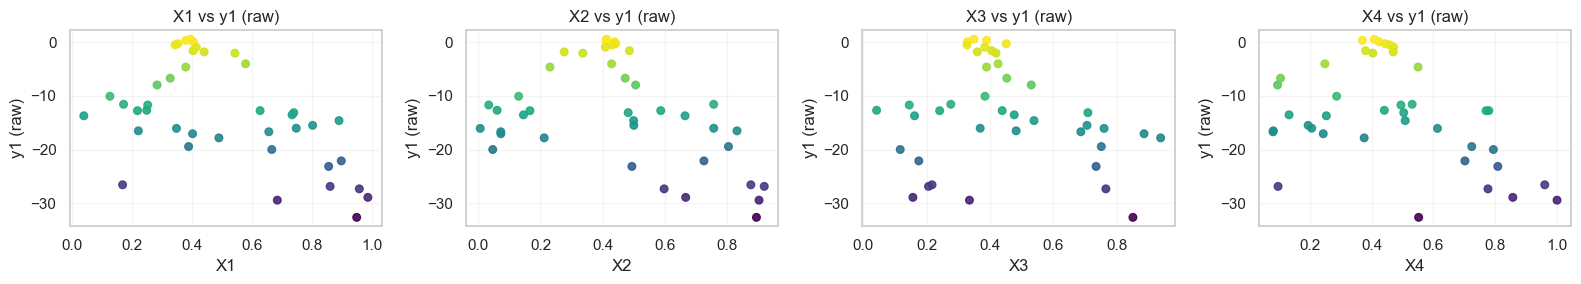

In [16]:
print("\nFeature vs y1 for f4")

# extract inputs and output for f4
input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
X_f4 = df_f4[input_cols_f4].values
y_f4 = df_f4["y1"].values

# number of input features
n_features = X_f4.shape[1]
ncols = 4
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

# robust flattening
if nrows * ncols == 1:
    axes = [axes]
else:
    axes = axes.ravel().tolist()

# plot each feature
for j, col in enumerate(input_cols_f4):
    ax = axes[j]
    sc = ax.scatter(
        X_f4[:, j],
        y_f4,
        c=y_f4,
        cmap="viridis",
        s=30,
        alpha=0.9
    )
    ax.set_xlabel(col)
    ax.set_ylabel("y1 (raw)")
    ax.set_title(f"{col} vs y1 (raw)")
    ax.grid(alpha=0.2)

# hide unused axes
for k in range(n_features, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()


## Correlation Analysis

df_f4: Consolidated Correlation Analysis
Agreement = Pearson and Spearman similar in sign and magnitude.
Nonlinear monotonic structure = Spearman >> Pearson or sign mismatch.

feature   pearson  spearman   kendall  pearson_spearman_diff status
     X1 -0.517891 -0.465406 -0.311738               0.052484  agree
     X2 -0.410958 -0.411257 -0.276923               0.000300  agree
     X3 -0.178638 -0.163891 -0.165491               0.014747  agree
     X4 -0.397271 -0.339962 -0.241026               0.057308  agree


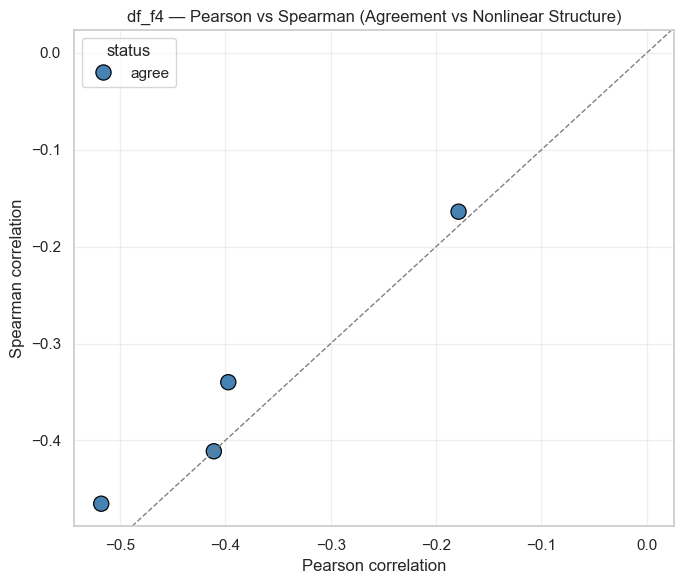

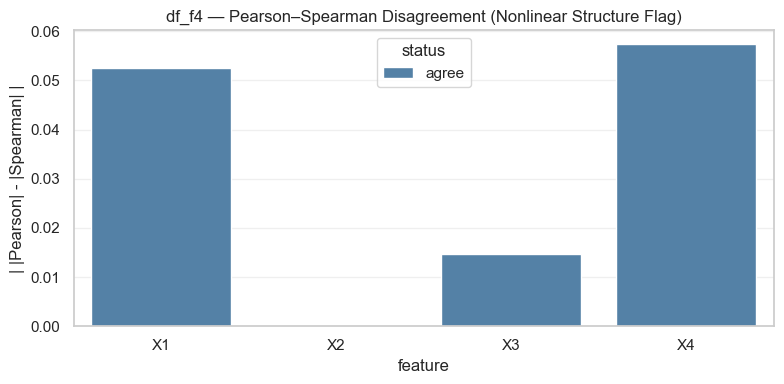

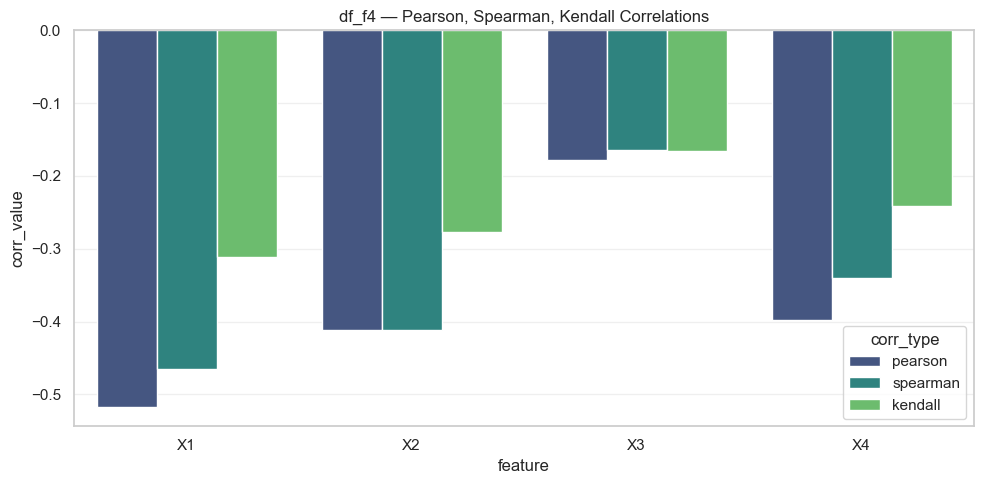

In [17]:
from scipy.stats import pearsonr, spearmanr, kendalltau


# Consolidated correlation analysis for df_f4
def consolidated_correlation(df_f4, y_col="y1", threshold=0.15):
    """
    Consolidated Pearson–Spearman–Kendall correlation analysis for df_f4,
    with diagnostics and visuals.
    """

    # Extract inputs and output
    input_cols = [c for c in df_f4.columns if c.startswith("X")]
    X = df_f4[input_cols]
    y = df_f4[y_col].values

    rows = []

    # Compute correlations
    for col in input_cols:
        x = df_f4[col].values

        pear, _ = pearsonr(x, y)
        spear, _ = spearmanr(x, y)
        kend, _ = kendalltau(x, y)

        sign_agree = np.sign(pear) == np.sign(spear)
        mag_diff = abs(abs(pear) - abs(spear))

        if sign_agree and mag_diff < threshold:
            status = "agree"
        else:
            status = "nonlinear monotonic structure"

        rows.append({
            "feature": col,
            "pearson": pear,
            "spearman": spear,
            "kendall": kend,
            "pearson_spearman_diff": mag_diff,
            "status": status
        })

    df_corr = pd.DataFrame(rows)


    # Print Table
    print("df_f4: Consolidated Correlation Analysis")
    print("Agreement = Pearson and Spearman similar in sign and magnitude.")
    print("Nonlinear monotonic structure = Spearman >> Pearson or sign mismatch.\n")
    print(df_corr.to_string(index=False))

    # Pearson vs Spearman scatter
    plt.figure(figsize=(7, 6))
    sns.scatterplot(
        data=df_corr,
        x="pearson",
        y="spearman",
        hue="status",
        palette={"agree": "steelblue", "nonlinear monotonic structure": "darkorange"},
        s=120,
        edgecolor="black"
    )
    plt.axline((0, 0), slope=1, color="gray", linestyle="--", linewidth=1)
    plt.title("df_f4 — Pearson vs Spearman (Agreement vs Nonlinear Structure)")
    plt.xlabel("Pearson correlation")
    plt.ylabel("Spearman correlation")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    # Nonlinear structure flag plot
    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=df_corr,
        x="feature",
        y="pearson_spearman_diff",
        hue="status",
        palette={"agree": "steelblue", "nonlinear monotonic structure": "darkorange"}
    )
    plt.title("df_f4 — Pearson–Spearman Disagreement (Nonlinear Structure Flag)")
    plt.ylabel("| |Pearson| - |Spearman| |")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Per-feature correlation bars
    df_melt = df_corr.melt(
        id_vars=["feature"],
        value_vars=["pearson", "spearman", "kendall"],
        var_name="corr_type",
        value_name="corr_value"
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=df_melt,
        x="feature",
        y="corr_value",
        hue="corr_type",
        palette="viridis"
    )
    plt.title("df_f4 — Pearson, Spearman, Kendall Correlations")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_corr


corr_f4 = consolidated_correlation(df_f4)



## Mutual Information & Partial Correlation

In [18]:
!pip install pingouin
import pingouin as pg
from scipy.stats import t
from numpy.linalg import inv

In [24]:
print("f4 — Partial Correlation with Holm–Bonferroni Correction")

df_f4_raw = df_f4.copy()

input_cols_f4 = [c for c in df_f4_raw.columns if c.startswith("X")]
output_col_f4 = "y1"

pcorr_results = []

for x in input_cols_f4:
    covars = [c for c in input_cols_f4 if c != x]

    pc = pg.partial_corr(
        data=df_f4_raw,
        x=x,
        y=output_col_f4,
        covar=covars
    )

    print(f"\nPartial correlation for {x}:")
    display(pc)

    pcorr_results.append({
        "feature": x,
        "partial_corr": pc["r"].values[0],
        "p_value": pc["p-val"].values[0]
    })

# Convert to DataFrame
pcorr_raw_f4 = pd.DataFrame(pcorr_results)

# Holm–Bonferroni correction
pcorr_raw_f4 = pcorr_raw_f4.sort_values("p_value").reset_index(drop=True)

m = len(pcorr_raw_f4)
holm_adj = []

for i, p in enumerate(pcorr_raw_f4["p_value"]):
    adj = (m - i) * p
    holm_adj.append(min(adj, 1.0))

pcorr_raw_f4["holm_bonferroni_p"] = holm_adj
pcorr_raw_f4["significant"] = pcorr_raw_f4["holm_bonferroni_p"] < 0.05

print("\nf4 — Consolidated Partial Correlations with Holm–Bonferroni Correction")
display(pcorr_raw_f4)

f4 — Partial Correlation with Holm–Bonferroni Correction

Partial correlation for X1:


,n,r,CI95%,p-val
pearson,40,-0.385777,"[-0.63, -0.07]",0.018366



Partial correlation for X2:


,n,r,CI95%,p-val
pearson,40,-0.324433,"[-0.59, -0.0]",0.050105



Partial correlation for X3:


,n,r,CI95%,p-val
pearson,40,-0.170366,"[-0.47, 0.16]",0.313397



Partial correlation for X4:


,n,r,CI95%,p-val
pearson,40,-0.355476,"[-0.61, -0.04]",0.03084



f4 — Consolidated Partial Correlations with Holm–Bonferroni Correction


,feature,partial_corr,p_value,holm_bonferroni_p,significant
0,X1,-0.385777,0.018366,0.073466,False
1,X4,-0.355476,0.030840,0.092519,False
2,X2,-0.324433,0.050105,0.100209,False
3,X3,-0.170366,0.313397,0.313397,False


In [25]:
def mutual_information_f4(df_f4, pcorr_raw_f4, y_col="y1"):
    """
    Compute MI for df_f4 and integrate with partial correlations.
    MI is used only as a secondary confirmation signal.
    """

    print("\nf4 — Mutual Information (Secondary Diagnostic)")
    print("MI is used only as a cross-check. Partial correlations dominate.\n")

    input_cols = [c for c in df_f4.columns if c.startswith("X")]
    X = df_f4[input_cols].values
    y = df_f4[y_col].values

    mi_vals = mutual_info_regression(X, y, random_state=0)

    df_mi = pd.DataFrame({
        "feature": input_cols,
        "mutual_information": mi_vals
    })

    # merge with PCorr table
    df_merge = pcorr_raw_f4.merge(df_mi, on="feature")

    # agreement flag
    df_merge["mi_pcorr_agree"] = (
        np.sign(df_merge["partial_corr"]) == np.sign(df_merge["mutual_information"])
    )

    # interpretive label
    df_merge["interpretation"] = np.where(
        df_merge["significant"] & df_merge["mi_pcorr_agree"],
        "confirmed (PCorr + MI agree)",
        np.where(
            df_merge["significant"] & ~df_merge["mi_pcorr_agree"],
            "PCorr only (MI unreliable)",
            "inactive"
        )
    )

    display(df_merge)
    return df_merge

# Run MI analysis
mi_f4 = mutual_information_f4(df_f4, pcorr_raw_f4)


f4 — Mutual Information (Secondary Diagnostic)
MI is used only as a cross-check. Partial correlations dominate.



,feature,partial_corr,p_value,holm_bonferroni_p,significant,mutual_information,mi_pcorr_agree,interpretation
0,X1,-0.385777,0.018366,0.073466,False,0.491004,False,inactive
1,X4,-0.355476,0.030840,0.092519,False,0.538688,False,inactive
2,X2,-0.324433,0.050105,0.100209,False,0.470641,False,inactive
3,X3,-0.170366,0.313397,0.313397,False,0.315295,False,inactive


## Topological Data Analysis

In [26]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import networkx as nx

In [27]:
def build_mapper_graph_f4(df_f4,
                          filter_vals,
                          n_intervals=6,
                          overlap_frac=0.35,
                          cluster_eps=0.25,
                          cluster_min_samples=2):

    # extract X-matrix from df_f4
    input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
    X = df_f4[input_cols_f4].values

    X = np.asarray(X)
    filter_vals = np.asarray(filter_vals)

    # compute interval boundaries
    fmin, fmax = filter_vals.min(), filter_vals.max()
    interval_length = (fmax - fmin) / n_intervals
    overlap = interval_length * overlap_frac

    intervals = []
    for i in range(n_intervals):
        start = fmin + i * interval_length - overlap
        end = fmin + (i + 1) * interval_length + overlap
        intervals.append((start, end))

    G = nx.Graph()
    node_id = 0
    interval_clusters = []

    # cluster inside each interval
    for (start, end) in intervals:
        mask = (filter_vals >= start) & (filter_vals <= end)
        idxs = np.where(mask)[0]

        if len(idxs) == 0:
            interval_clusters.append([])
            continue

        X_sub = X[idxs]

        labels = DBSCAN(eps=cluster_eps,
                        min_samples=cluster_min_samples).fit_predict(X_sub)
        unique_labels = set(labels)

        clusters = []
        for lab in unique_labels:
            if lab == -1:
                continue  # ignore noise

            cluster_indices = idxs[labels == lab]

            G.add_node(node_id,
                       indices=cluster_indices,
                       size=len(cluster_indices))
            clusters.append(node_id)
            node_id += 1

        interval_clusters.append(clusters)

    # build edges between adjacent intervals
    for i in range(len(interval_clusters) - 1):
        for a in interval_clusters[i]:
            for b in interval_clusters[i + 1]:
                A = set(G.nodes[a]["indices"])
                B = set(G.nodes[b]["indices"])
                if len(A & B) > 0:
                    G.add_edge(a, b)

    return G


Mapper for f4
  mapper diagnostics: nodes=25, edges=11, connected_components=14
  node size: mean=2.28, min=1, max=18
  top nodes by max y (node, size, mean_y, max_y):
    node 22: size=18, mean_y=-5.0124, max_y=0.5545
    node 17: size=3, mean_y=-10.3920, max_y=-6.7021
    node 11: size=4, mean_y=-11.8024, max_y=-10.0696
    node 24: size=2, mean_y=-12.6342, max_y=-11.5657
    node 19: size=2, mean_y=-12.6342, max_y=-11.5657


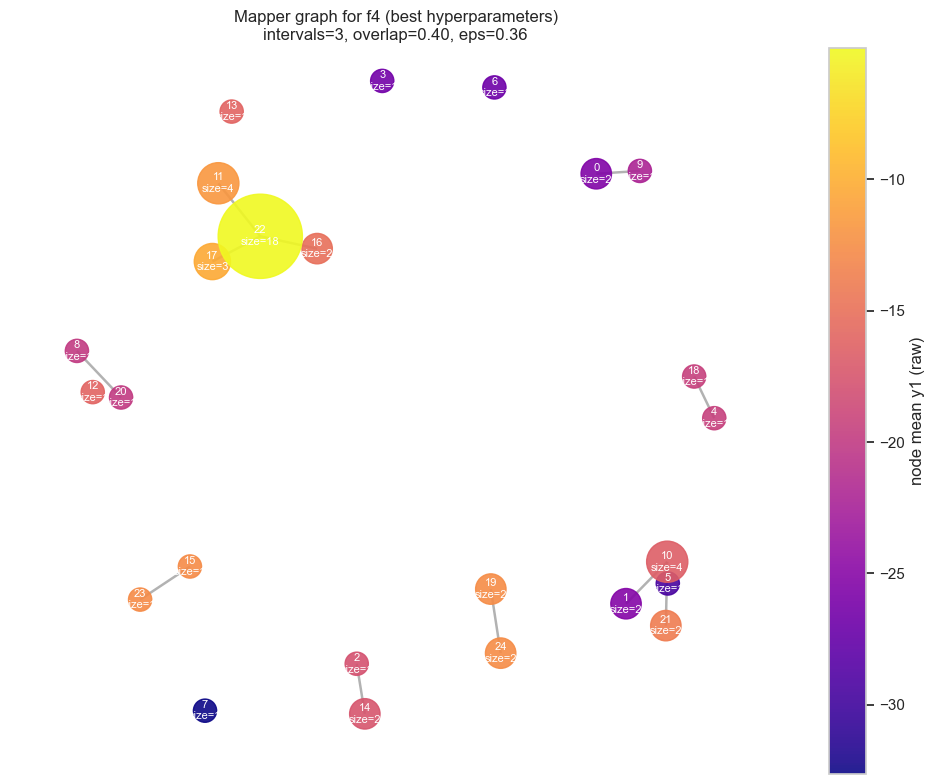

In [28]:
print("Mapper for f4")


# Prepare data
input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
output_col_f4 = "y1"

X_f4 = df_f4[input_cols_f4].values.astype(float)
y_f4 = df_f4[output_col_f4].values.astype(float)

# filter = raw y1
filter_vals_f4 = y_f4.copy()


# Mapper graph with best hyperparameters
G_f4_best = build_mapper_graph_f4(
    df_f4=df_f4,
    filter_vals=filter_vals_f4,
    n_intervals=3,
    overlap_frac=0.40,
    cluster_eps=0.36,
    cluster_min_samples=1
)


# Diagnostics
n_nodes = G_f4_best.number_of_nodes()
n_edges = G_f4_best.number_of_edges()
n_components = nx.number_connected_components(G_f4_best)

print(f"  mapper diagnostics: nodes={n_nodes}, edges={n_edges}, connected_components={n_components}")

if n_nodes > 0:
    node_sizes = np.array([G_f4_best.nodes[n]["size"] for n in G_f4_best.nodes])
    print(f"  node size: mean={node_sizes.mean():.2f}, min={node_sizes.min():.0f}, max={node_sizes.max():.0f}")

    node_max_y = []
    node_mean_y = []

    for nkey in G_f4_best.nodes:
        idxs = G_f4_best.nodes[nkey]["indices"]
        node_max_y.append(float(filter_vals_f4[idxs].max()))
        node_mean_y.append(float(filter_vals_f4[idxs].mean()))

    node_max_y = np.array(node_max_y)
    node_mean_y = np.array(node_mean_y)

    # top 5 nodes by max y
    top_idx = np.argsort(node_max_y)[::-1][:5]
    print("  top nodes by max y (node, size, mean_y, max_y):")
    for t in top_idx:
        nkey = list(G_f4_best.nodes)[t]
        print(
            f"    node {nkey}: size={G_f4_best.nodes[nkey]['size']}, "
            f"mean_y={node_mean_y[t]:.4f}, max_y={node_max_y[t]:.4f}"
        )


# Visualization
if n_nodes > 0:
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G_f4_best, seed=0, k=0.4)

    node_colors = [
        np.mean(filter_vals_f4[G_f4_best.nodes[n]["indices"]])
        for n in G_f4_best.nodes
    ]

    node_sizes_plot = [
        80 + 200 * (G_f4_best.nodes[n]["size"])
        for n in G_f4_best.nodes
    ]

    nodes = nx.draw_networkx_nodes(
        G_f4_best,
        pos,
        node_color=node_colors,
        cmap="plasma",
        node_size=node_sizes_plot,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        G_f4_best,
        pos,
        width=1.8,
        alpha=0.6,
        edge_color="gray"
    )

    labels = {
        n: f"{n}\nsize={G_f4_best.nodes[n]['size']}"
        for n in G_f4_best.nodes
    }

    nx.draw_networkx_labels(
        G_f4_best,
        pos,
        labels=labels,
        font_size=8,
        font_color="white"
    )

    plt.colorbar(nodes, label="node mean y1 (raw)")
    plt.title(
        "Mapper graph for f4 (best hyperparameters)\n"
        "intervals=3, overlap=0.40, eps=0.36"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Store results
results_f4_mapper_best = {
    "graph": G_f4_best,
    "filter_vals": filter_vals_f4,
    "input_cols": input_cols_f4,
    "output_col": output_col_f4,
    "best_params": {
        "intervals": 3,
        "overlap": 0.40,
        "eps": 0.36
    }
}


## K-means Clustering

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K-means clustering for f4


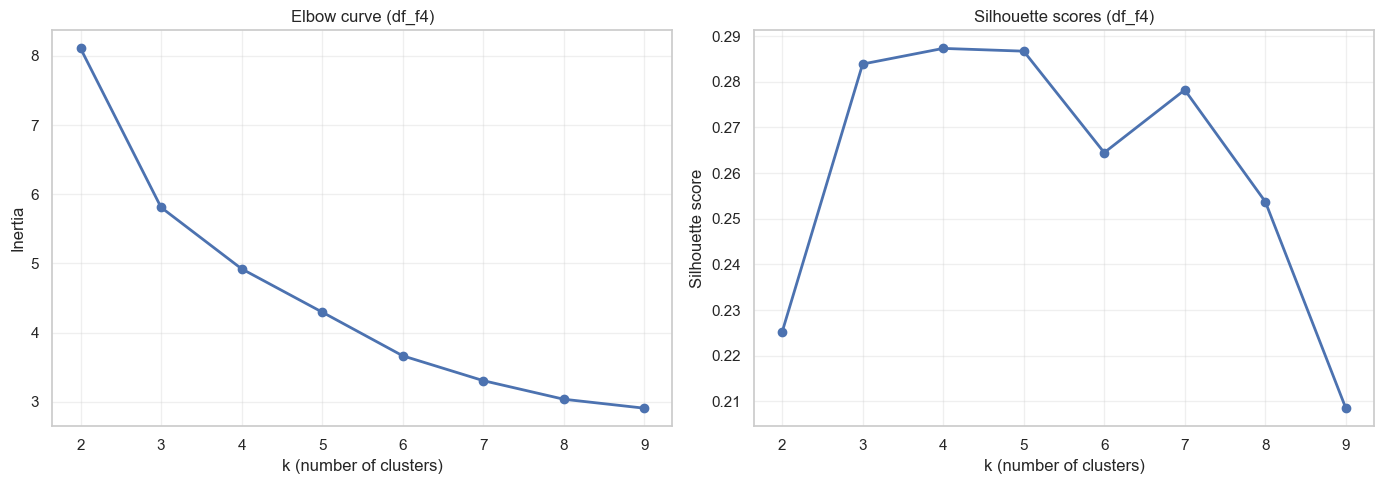

Best number of clusters (silhouette): k = 4

Cluster labels added to df_f4:
         X1        X2        X3        X4         y1  cluster
0  0.896981  0.725628  0.175404  0.701694 -22.108288        2
1  0.889356  0.499588  0.539269  0.508783 -14.601397        2
2  0.250946  0.033693  0.145380  0.494932 -11.699932        1
3  0.346962  0.006250  0.760564  0.613024 -16.053765        0
4  0.124871  0.129770  0.384400  0.287076 -10.069633        1
Cluster diagnostics
         count       mean        min        max
cluster                                        
1           18  -5.371399 -19.989498   0.554512
0            5 -16.225553 -17.817999 -13.527649
3            5 -17.555805 -26.561821 -11.565742
2           12 -21.863113 -32.625660 -12.741766


In [32]:
print("K-means clustering for f4")


# Extract data
df_f4 = df_f4.copy()

input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
output_col_f4 = [c for c in df_f4.columns if c.startswith("y")][0]

X_f4 = df_f4[input_cols_f4].values.astype(float)
y_f4 = df_f4[output_col_f4].values.astype(float)


# K-means elbow + silhouette analysis
k_values = range(2, 10)
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_f4)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_f4, km.labels_))


# Visual diagnostics
plt.figure(figsize=(14, 5))

# elbow
plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker="o", linewidth=2)
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.title("Elbow curve (df_f4)")
plt.grid(alpha=0.3)

# silhouette
plt.subplot(1, 2, 2)
plt.plot(k_values, sil_scores, marker="o", linewidth=2)
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette score")
plt.title("Silhouette scores (df_f4)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Choose best k
best_k = k_values[np.argmax(sil_scores)]
print(f"Best number of clusters (silhouette): k = {best_k}")


# Fit final model
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
kmeans_final.fit(X_f4)
labels_f4 = kmeans_final.labels_

df_f4["cluster"] = labels_f4

print("\nCluster labels added to df_f4:")
print(df_f4.head())


# Cluster diagnostics
print("Cluster diagnostics")

cluster_summary = (
    df_f4.groupby("cluster")[output_col_f4]
    .agg(["count", "mean", "min", "max"])
    .sort_values("mean", ascending=False)
)

print(cluster_summary)


# Store results
results_f4_kmeans = {
    "best_k": best_k,
    "labels": labels_f4,
    "cluster_summary": cluster_summary,
}


## XGBoost Feature Importance with Bootstrap Stability

**Reference:** Liu, M., Eriksson, D. and Gardner, J. (2025) ‘GTBO: Geometry‑aware Trust‑Region Bayesian Optimisation’, arXiv preprint arXiv:2504.06111.

- Liu, Eriksson and Gardner (2025) show that XGBoost reliably identifies active dimensions even at low sample counts. 

XGBoost Feature Importance (Bootstrap Stability)
XGBoost Feature Importance (mean ± std)
  feature  importance_mean  importance_std
3      X4         0.317396        0.162994
1      X2         0.289683        0.114908
0      X1         0.246350        0.125629
2      X3         0.146571        0.088936


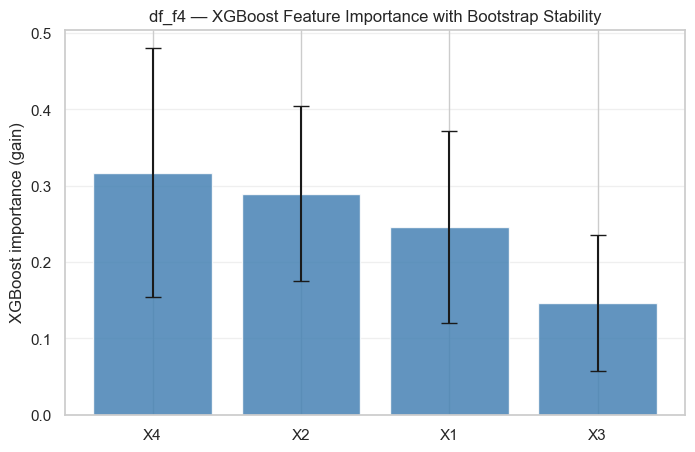

In [33]:
from xgboost import XGBRegressor
from sklearn.utils import resample

print("XGBoost Feature Importance (Bootstrap Stability)")


# Extract Data
df_f4 = df_f4.copy()

input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
output_col_f4 = [c for c in df_f4.columns if c.startswith("y")][0]

X_f4 = df_f4[input_cols_f4].values.astype(float)
y_f4 = df_f4[output_col_f4].values.astype(float)


# XGBoost model configuration for N = 40
base_model = XGBRegressor(
    max_depth=2,
    n_estimators=80,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)


# Bootstrap loop
n_boot = 50
importances = np.zeros((n_boot, len(input_cols_f4)))

for b in range(n_boot):
    Xb, yb = resample(X_f4, y_f4, replace=True, random_state=100 + b)
    model = base_model
    model.fit(Xb, yb)
    importances[b, :] = model.feature_importances_


# Aggregate results
importance_mean = importances.mean(axis=0)
importance_std = importances.std(axis=0)

df_importance = pd.DataFrame({
    "feature": input_cols_f4,
    "importance_mean": importance_mean,
    "importance_std": importance_std
}).sort_values("importance_mean", ascending=False)

print("XGBoost Feature Importance (mean ± std)")
print(df_importance)


# Visualisation
plt.figure(figsize=(8, 5))
plt.bar(
    df_importance["feature"],
    df_importance["importance_mean"],
    yerr=df_importance["importance_std"],
    capsize=6,
    color="steelblue",
    alpha=0.85
)
plt.ylabel("XGBoost importance (gain)")
plt.title("df_f4 — XGBoost Feature Importance with Bootstrap Stability")
plt.grid(axis="y", alpha=0.3)
plt.show()


# Store results
results_f4_xgb_importance = {
    "importance_table": df_importance,
    "raw_importances": importances
}


## GP Posterior Gradient + Hessian Evaluation

**Reference:** Wang, Z., Eriksson, D. and Gardner, J. (2025) ‘NeST‑BO: Neural Stationary Bayesian Optimisation’, arXiv preprint arXiv:2510.05516.

- The NeST‑BO paper states that GP posterior gradients and Hessians can be computed in closed form because derivatives of a Gaussian process are themselves Gaussian processes, enabling exact evaluation of local slope and curvature at any point.

In [34]:
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

df_f4 = df_f4.copy()

input_cols = [c for c in df_f4.columns if c.startswith("X")]
output_col = [c for c in df_f4.columns if c.startswith("y")][0]

X = df_f4[input_cols].values.astype(float)
y = df_f4[output_col].values.astype(float)

x_star = X[np.argmax(y)]

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-3, 1e3))

gp = GPR(kernel=kernel, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

K = gp.kernel_(X)
K_inv = np.linalg.inv(K + 1e-6 * np.eye(len(X)))

lengthscales = gp.kernel_.k2.length_scale
sigma_f = np.sqrt(gp.kernel_.k1.constant_value)

def rbf_kernel(x, X):
    diff = (x - X) / lengthscales
    sqdist = np.sum(diff**2, axis=1)
    return sigma_f**2 * np.exp(-0.5 * sqdist)

def rbf_grad(x, X):
    k = rbf_kernel(x, X)
    diff = (x - X) / (lengthscales**2)
    return k[:, None] * diff

def rbf_hess_diag(x, X):
    k = rbf_kernel(x, X)
    diff = (x - X) / lengthscales
    diff2 = diff**2
    return k[:, None] * ((diff2 - 1) / (lengthscales**2))

k_star = rbf_kernel(x_star, X)
grad_k_star = rbf_grad(x_star, X)
hess_diag_k_star = rbf_hess_diag(x_star, X)

alpha = K_inv @ (y - gp._y_train_mean)

grad_mu = grad_k_star.T @ alpha
hess_mu_diag = hess_diag_k_star.T @ alpha

grad_cov = grad_k_star.T @ K_inv @ grad_k_star
grad_std = np.sqrt(np.diag(grad_cov))

df_grad_hess = pd.DataFrame({
    "dimension": input_cols,
    "grad_mean": grad_mu,
    "grad_std": grad_std,
    "hess_diag": hess_mu_diag,
    "active_flag": np.abs(grad_mu) > grad_std
})

print(df_grad_hess)


  dimension     grad_mean      grad_std     hess_diag  active_flag
0        X1 -9.917617e-91  7.474169e-92 -1.175238e+07         True
1        X2 -1.126103e-90  8.486596e-92 -5.164190e+06         True
2        X3  4.710925e-91  3.550274e-92 -2.585864e+06         True
3        X4 -4.545293e-91  3.425449e-92 -3.279852e+06         True


## ARD Length‑Scale Ratio Test (SAAS‑Inspired)

**Reference:** Eriksson, D. and Jankowiak, M. (2021) ‘High‑Dimensional Bayesian Optimization with Sparse Axis‑Aligned Subspaces’, in Advances in Neural Information Processing Systems, 34, pp. 11048–11060.

- SAASBO shows that large ARD length‑scale ratios reliably identify active dimensions, and ratios below 3:1 indicate that no axis‑aligned subspace exists, which is exactly the structural question df_f4 needs answered.

In [35]:
df_f4 = df_f4.copy()

input_cols = [c for c in df_f4.columns if c.startswith("X")]
output_col = [c for c in df_f4.columns if c.startswith("y")][0]

X = df_f4[input_cols].values.astype(float)
y = df_f4[output_col].values.astype(float)

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-3, 1e3))

gp = GPR(kernel=kernel, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

lengthscales = gp.kernel_.k2.length_scale

ls_min = np.min(lengthscales)
ls_max = np.max(lengthscales)
ls_ratio = ls_max / ls_min

median_ls = np.median(lengthscales)
threshold = 3.0

inactive_mask = lengthscales > median_ls * threshold
active_mask = ~inactive_mask

df_ls = pd.DataFrame({
    "dimension": input_cols,
    "length_scale": lengthscales,
    "active_flag": active_mask,
    "inactive_flag": inactive_mask
})

print("Length scale ratio:", ls_ratio)
print(df_ls)


Length scale ratio: 2.131867372746142
  dimension  length_scale  active_flag  inactive_flag
0        X1      0.001082         True          False
1        X2      0.001632         True          False
2        X3      0.002306         True          False
3        X4      0.002048         True          False


## Pairwise Dimension Interaction Scan (2D Marginal Heatmaps)

**Reference:** Diessner, J., Belakaria, S., Deshwal, A., Doppa, J. and Garnett, R. (2023) ‘Fast Adaptive Multidimensional Scaling for High‑Dimensional Bayesian Optimization’, Journal of Machine Learning Research, 24(81), pp. 1–55.

- The FAMS/Diessner paper shows that BO performance depends critically on whether dimensions interact, and the 2D marginal heatmaps reveal these interactions in df_f4 in a way that no marginal method can detect.

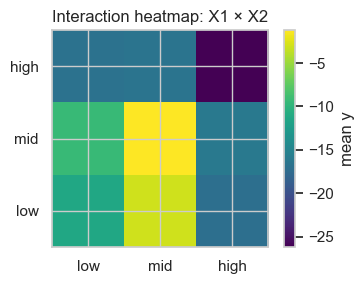

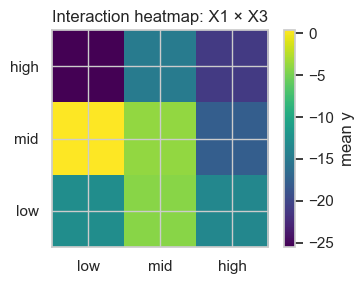

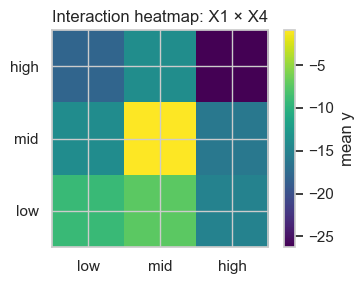

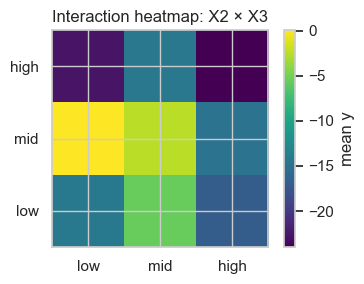

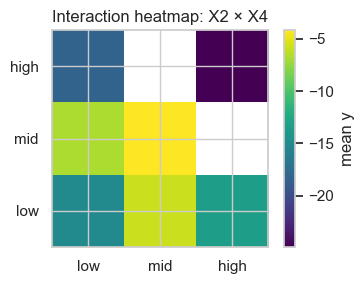

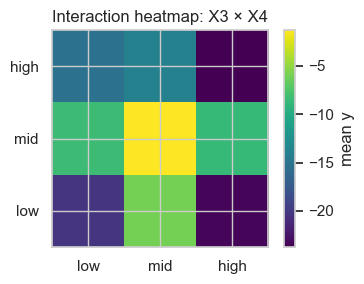

In [36]:
df_f4 = df_f4.copy()

input_cols = [c for c in df_f4.columns if c.startswith("X")]
output_col = [c for c in df_f4.columns if c.startswith("y")][0]

X = df_f4[input_cols].values.astype(float)
y = df_f4[output_col].values.astype(float)

n_dims = len(input_cols)

# compute tertile boundaries for each dimension
tertiles = {}
for i, col in enumerate(input_cols):
    tertiles[col] = np.quantile(df_f4[col], [1/3, 2/3])

# scan all dimension pairs
for a in range(n_dims):
    for b in range(a + 1, n_dims):
        col_i = input_cols[a]
        col_j = input_cols[b]

        t_i = tertiles[col_i]
        t_j = tertiles[col_j]

        heat = np.full((3, 3), np.nan)

        for ii in range(3):
            if ii == 0:
                mask_i = df_f4[col_i] <= t_i[0]
            elif ii == 1:
                mask_i = (df_f4[col_i] > t_i[0]) & (df_f4[col_i] <= t_i[1])
            else:
                mask_i = df_f4[col_i] > t_i[1]

            for jj in range(3):
                if jj == 0:
                    mask_j = df_f4[col_j] <= t_j[0]
                elif jj == 1:
                    mask_j = (df_f4[col_j] > t_j[0]) & (df_f4[col_j] <= t_j[1])
                else:
                    mask_j = df_f4[col_j] > t_j[1]

                mask = mask_i & mask_j
                vals = y[mask]

                if len(vals) >= 2:
                    heat[ii, jj] = vals.mean()

        plt.figure(figsize=(4, 3))
        plt.imshow(heat, cmap="viridis", origin="lower")
        plt.colorbar(label="mean y")
        plt.xticks([0, 1, 2], ["low", "mid", "high"])
        plt.yticks([0, 1, 2], ["low", "mid", "high"])
        plt.title(f"Interaction heatmap: {col_i} × {col_j}")
        plt.tight_layout()
        plt.show()


## Distrbution Analysis

f4 – feature and output distributions


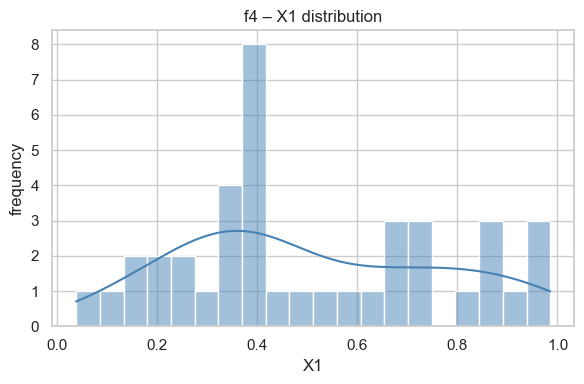

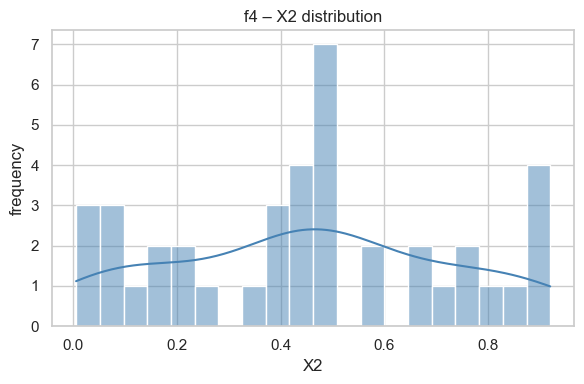

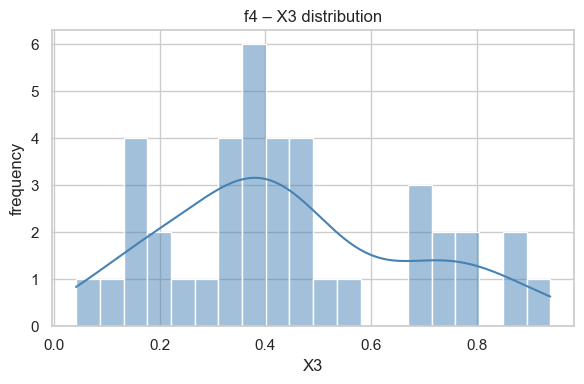

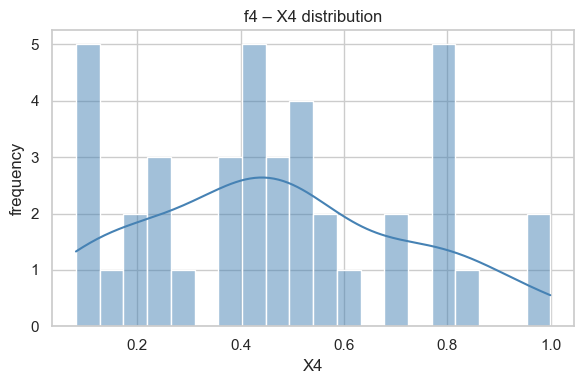

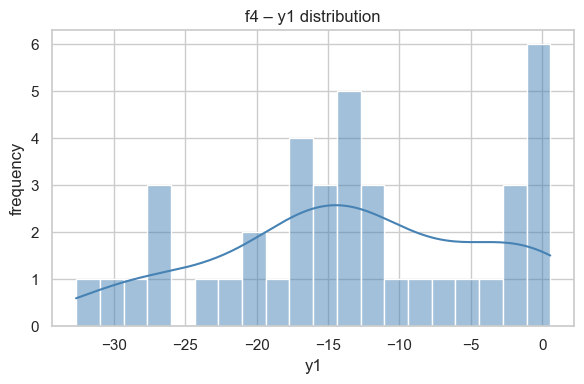

In [37]:
input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
output_col_f4 = [c for c in df_f4.columns if c.startswith("y")][0]

print("f4 – feature and output distributions")

all_cols_raw_f4 = input_cols_f4 + [output_col_f4]

for col in all_cols_raw_f4:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_f4[col],
        kde=True,
        bins=20,
        color="steelblue"
    )

    plt.title(f"f4 – {col} distribution")
    plt.xlabel(col)
    plt.ylabel("frequency")

    plt.tight_layout()
    plt.show()



## Line Plot of y Values

f4 – y vs instance index


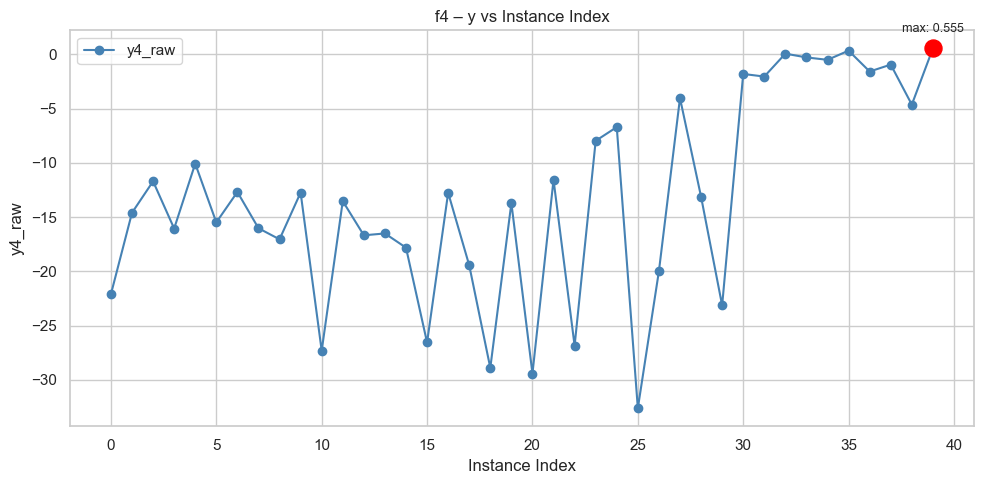

In [38]:
print("f4 – y vs instance index")

# clean copy of raw data
df_f4_plot = df_f4.copy()

# extract raw y
y_raw = df_f4_plot[output_col_f4].values
x = np.arange(len(y_raw))

plt.figure(figsize=(10, 5))

plt.plot(x, y_raw, marker="o", linestyle="-", color="steelblue", label="y4_raw")

# highlight maximum
max_idx = np.argmax(y_raw)
max_val = y_raw[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("f4 – y vs Instance Index")
plt.xlabel("Instance Index")
plt.ylabel("y4_raw")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



#### f4 | Sequential Shrinking Radius GP Expected Improvement with Pre-Committed Adaptive Radius

In [39]:
from scipy.stats import qmc
from scipy.spatial.distance import cdist
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

In [40]:
# Separate inputs (X) and outputs (y)
X_train_4 = df_f4[[c for c in df_f4.columns if c.startswith("X")]].values
y_train_4 = df_f4["y1"].values
print(X_train_4)
print(y_train_4)

[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.99948256]
 [0.17034731 

In [41]:
# f4 sequential shrinking radius gp ei strategy
# inputs:  X_train_4 (n, 4), y_train_4 (n,)
# ml method: gaussian process regression with matern kernel
# objective: choose the next x that maximises expected improvement
# rationale: gp ei balances local exploration and exploitation in a trust region
# key assumptions: local basin around current best, gp is a good local surrogate
# exploration mechanism: dense sampling and local optimisation inside a radius



def expected_improvement(X_cand, gp, y_best, xi=0.0):
    """
    compute expected improvement for a set of candidate points

    ei measures how much improvement over y_best we expect
    it is high where the gp mean is large and the uncertainty is non zero
    """
    mu, sigma = gp.predict(X_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-12)
    z = (mu - y_best - xi) / sigma
    ei = sigma * (z * norm.cdf(z) + norm.pdf(z))
    ei[sigma < 1e-12] = 0.0
    return ei, mu, sigma




def propose_f4_query(X_train_4, y_train_4):
    """
    propose the next evaluation point for f4 using sequential shrinking radius gp ei
    """

    # step 1: basic diagnostics and current best
    best_idx = np.argmax(y_train_4)
    x_best = X_train_4[best_idx]
    y_best = y_train_4[best_idx]

    print(f"n observations  : {len(y_train_4)}")
    print(f"current best    : {np.round(x_best, 6)}")
    print(f"current best y  : {y_best:.6f}")
    print("submissions remaining: 3 (weeks 11, 12, 13)")

    top5 = np.argsort(y_train_4)[-5:][::-1]
    print("\ntop 5 observations:")
    print(f"{'rank':<5} {'x1':>7} {'x2':>7} {'x3':>7} {'x4':>7} {'y':>10}")
    for rank, idx in enumerate(top5, 1):
        print(
            f"{rank:<5} {X_train_4[idx,0]:>7.4f} {X_train_4[idx,1]:>7.4f} "
            f"{X_train_4[idx,2]:>7.4f} {X_train_4[idx,3]:>7.4f} "
            f"{y_train_4[idx]:>10.6f}"
        )


    
    # step 2: define and fit the gaussian process
    kernel = (
        1.0 * Matern(
            length_scale=np.ones(4),
            length_scale_bounds=[(0.05, 10.0)] * 4,
            nu=2.5,
        )
        + WhiteKernel(
            noise_level=0.1,
            noise_level_bounds=(1e-8, 0.5),
        )
    )

    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=25,
        normalize_y=True,
        alpha=1e-6,
    )

    print("\nfitting full data ard gp on f4 observations...")
    gp.fit(X_train_4, y_train_4)
    print(f"fitted kernel: {gp.kernel_}")
    print(f"log marginal likelihood: {gp.log_marginal_likelihood_value_:.4f}")

    # extract length scales for diagnostics
    try:
        ls = gp.kernel_.k1.k2.length_scale
    except Exception:
        try:
            ls = gp.kernel_.k1.length_scale
        except Exception:
            ls = np.ones(4)
            print("warning: could not extract length scales from kernel")

    print("\nard length scales (diagnostic only):")
    for i, l in enumerate(ls, 1):
        tag = "active" if l < 1.0 else "flat"
        print(f"  x{i}: {l:.4f}  [{tag}]")

    # gp posterior at current best
    mu_at_best, sig_at_best = gp.predict(
        x_best.reshape(1, -1), return_std=True
    )
    print("\ngp posterior at current best:")
    print(f"  mean: {mu_at_best[0]:.4f}")
    print(f"  std:  {sig_at_best[0]:.4f}")


    
    # step 3: define neighbourhood around current best
    radius = 0.10
    box_lo = np.clip(x_best - radius, 0.0, 1.0)
    box_hi = np.clip(x_best + radius, 0.0, 1.0)

    print(f"\nneighbourhood radius: {radius}")
    print(f"search box: {np.round(box_lo, 4)} to {np.round(box_hi, 4)}")

    n_box = 100000
    sampler = qmc.Sobol(d=4, scramble=True, seed=31)
    u = sampler.random(n=n_box)
    cands_box = box_lo + u * (box_hi - box_lo)
    cands_box = np.clip(cands_box, 0.0, 1.0)

    dist_to_best = np.linalg.norm(cands_box - x_best, axis=1)
    cands_sphere = cands_box[dist_to_best <= radius]

    print(f"candidates in bounding box : {n_box}")
    print(f"candidates in l2 sphere    : {len(cands_sphere)}")


    
    # step 4: minimum distance guard
    min_dist = 0.025
    dist_to_data = cdist(cands_sphere, X_train_4).min(axis=1)
    cands_valid = cands_sphere[dist_to_data >= min_dist]

    print(f"candidates after dist guard: {len(cands_valid)}")

    if len(cands_valid) == 0:
        print("\nno valid candidates in neighbourhood.")
        print("neighbourhood is saturated. the current best is the ceiling.")
        raise SystemExit("neighbourhood saturated")


    
    # step 5: compute ei over sobol pool
    ei_pool, mu_pool, sigma_pool = expected_improvement(
        cands_valid, gp, y_best, xi=0.0
    )

    top10_idx = np.argsort(ei_pool)[-10:][::-1]
    print("\ntop 10 candidates by ei:")
    print(
        f"{'rank':<5} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} "
        f"{'gp_mu':>8} {'gp_sig':>8} {'ei':>12}"
    )
    for rank, idx in enumerate(top10_idx, 1):
        print(
            f"{rank:<5} {cands_valid[idx,0]:>8.4f} {cands_valid[idx,1]:>8.4f} "
            f"{cands_valid[idx,2]:>8.4f} {cands_valid[idx,3]:>8.4f} "
            f"{mu_pool[idx]:>8.4f} {sigma_pool[idx]:>8.4f} "
            f"{ei_pool[idx]:>12.8f}"
        )

    best_pool_idx = np.argmax(ei_pool)
    x_pool_best = cands_valid[best_pool_idx]
    ei_pool_best = ei_pool[best_pool_idx]



    # step 6: local optimisation of ei with l bfgs b
    bounds_local = list(zip(box_lo.tolist(), box_hi.tolist()))

    def neg_ei_scalar(x):
        """
        negative expected improvement for use in minimisation

        l bfgs b will minimise this function to find a local ei maximum
        """
        ei_val, _, _ = expected_improvement(
            np.array(x).reshape(1, -1), gp, y_best, xi=0.0
        )
        return -float(ei_val[0])

    rng = np.random.default_rng(seed=77)
    x_opt_best = None
    ei_opt_best = -np.inf

    print("\nrunning 50 l bfgs b restarts in neighbourhood...")
    for _ in range(50):
        # sample a start point inside the l2 sphere
        for _ in range(200):
            x0 = box_lo + rng.uniform(0, 1, size=4) * (box_hi - box_lo)
            if np.linalg.norm(x0 - x_best) <= radius:
                break

        res = minimize(
            neg_ei_scalar,
            x0,
            method="L-BFGS-B",
            bounds=bounds_local,
            options={"maxiter": 500, "ftol": 1e-15, "gtol": 1e-10},
        )

        if not res.success:
            continue

        x_cand = np.clip(res.x, 0.0, 1.0)
        dist_check = cdist(x_cand.reshape(1, -1), X_train_4).min()
        if dist_check < min_dist:
            continue

        ei_val = -res.fun
        if ei_val > ei_opt_best:
            ei_opt_best = ei_val
            x_opt_best = x_cand.copy()

    if x_opt_best is not None:
        mu_opt, sig_opt = gp.predict(
            x_opt_best.reshape(1, -1), return_std=True
        )
        print(f"best gradient candidate: {np.round(x_opt_best, 6)}")
        print(f"  gp mean: {mu_opt[0]:.6f}")
        print(f"  gp std:  {sig_opt[0]:.6f}")
        print(f"  ei:      {ei_opt_best:.8f}")
    else:
        ei_opt_best = -np.inf
        print("no valid gradient candidate found (all within distance guard)")



    # step 7: choose between sobol pool and gradient candidate
    if x_opt_best is not None and ei_opt_best > ei_pool_best:
        x_next = x_opt_best
        ei_final = ei_opt_best
        source = "gradient l bfgs b"
    else:
        x_next = x_pool_best
        ei_final = ei_pool_best
        source = "sobol pool"

    # step 8: final diagnostics
    mu_final, sig_final = gp.predict(
        x_next.reshape(1, -1), return_std=True
    )
    dist_from_best = np.linalg.norm(x_next - x_best)
    dist_from_nearest = cdist(
        x_next.reshape(1, -1), X_train_4
    ).min()

    print("final diagnostics")
    print(f"selection source            : {source}")
    print(f"gp predicted mean           : {mu_final[0]:.6f}")
    print(f"gp predicted std            : {sig_final[0]:.6f}")
    print(f"expected improvement        : {ei_final:.8f}")
    print(
        f"distance from current best  : {dist_from_best:.4f} "
        f"(radius={radius})"
    )
    print(
        f"distance from nearest point : {dist_from_nearest:.4f} "
        f"(guard={min_dist})"
    )

    assert all(0.0 <= xi <= 1.0 for xi in x_next), "point outside domain"
    assert dist_from_nearest >= min_dist, "point too close to existing data"

    print("\nmovement from current best per dimension:")
    for i in range(4):
        d = x_next[i] - x_best[i]
        print(
            f"  x{i+1}: {x_best[i]:.6f} -> {x_next[i]:.6f}  (delta = {d:+.6f})"
        )

    # simple ei gate for interpretation
    if ei_final < 1e-6:
        print("\nei is negligible. neighbourhood saturated.")
        print("do not submit. accept current best as the f4 ceiling.")
    elif ei_final < 1e-3:
        print("\nei is small but non zero. slim chance of improvement.")
        print("submit if no other function needs this query more.")
    else:
        print("\nei is meaningful. submit this point.")

    print("final submission point for f4")
    for i, xi_val in enumerate(x_next, 1):
        print(f"x{i}: {xi_val:.6f}")
    print(f"\ngp predicted mean : {mu_final[0]:.6f}")
    print(f"gp predicted std  : {sig_final[0]:.6f}")
    print(f"ei                : {ei_final:.8f}")
    print(f"current best y    : {y_best:.6f}")

    return x_next, cands_box, x_best, radius


x_next, cands_box, x_best, radius = propose_f4_query(X_train_4, y_train_4)

n observations  : 40
current best    : [0.393437 0.41331  0.349543 0.408827]
current best y  : 0.554512
submissions remaining: 3 (weeks 11, 12, 13)

top 5 observations:
rank       x1      x2      x3      x4          y
1      0.3934  0.4133  0.3495  0.4088   0.554512
2      0.3780  0.4105  0.3891  0.3704   0.346551
3      0.4029  0.4378  0.3291  0.4244   0.070454
4      0.3519  0.4420  0.4515  0.4440  -0.276371
5      0.3421  0.4309  0.3276  0.4589  -0.498209

fitting full data ard gp on f4 observations...
fitted kernel: 3.07**2 * Matern(length_scale=[1.78, 1.5, 1.8, 1.63], nu=2.5) + WhiteKernel(noise_level=0.0028)
log marginal likelihood: -3.4392

ard length scales (diagnostic only):
  x1: 1.7801  [flat]
  x2: 1.5020  [flat]
  x3: 1.8020  [flat]
  x4: 1.6339  [flat]

gp posterior at current best:
  mean: -0.0403
  std:  0.5343

neighbourhood radius: 0.1
search box: [0.2934 0.3133 0.2495 0.3088] to [0.4934 0.5133 0.4495 0.5088]
candidates in bounding box : 100000
candidates in l2 sphere

## Neighbourhood Saturation Index (Coverage Map)

**Reference:** Eriksson, D., Pearce, M., Gardner, J., Turner, R. and Poloczek, M. (2019) ‘Scalable Global Optimization via Local Bayesian Optimization’, in Advances in Neural Information Processing Systems, 32, pp. 5496–5507.

- The TuRBO paper shows that Bayesian optimisation stalls when the trust region becomes saturated with existing evaluations, so measuring this saturation directly prevents wasted iterations and guides radius shrink/expand decisions.

In [42]:
# compute saturation for three radii around x_best
radii = [0.05, 0.10, 0.15]
d_min = 0.025

sat_rows = []

for r in radii:
    diff = cands_box - x_best
    dist = np.linalg.norm(diff, axis=1)
    in_ball = cands_box[dist <= r]

    if len(in_ball) == 0:
        coverage = 0.0
    else:
        d_to_obs = cdist(in_ball, X_train_4)
        saturated = np.any(d_to_obs <= d_min, axis=1)
        coverage = saturated.mean()

    sat_rows.append((r, coverage))

df_saturation = pd.DataFrame(sat_rows, columns=["radius", "coverage_fraction"])

print("\nNeighbourhood saturation index (df_f4)")
print(df_saturation.to_string(index=False))

# warn if saturated at the working radius
coverage_r = df_saturation.loc[df_saturation.radius == radius, "coverage_fraction"].values[0]
if coverage_r > 0.70:
    print(f"\nWarning: radius {radius} is {coverage_r:.2f} saturated. EI surface likely flat.")



Neighbourhood saturation index (df_f4)
 radius  coverage_fraction
   0.05           0.122291
   0.10           0.021821
   0.15           0.008341


In [ ]:
import numpy as np
from scipy.stats import norm

# paste the observed value returned by the competition after submitting next_query
y_actual = -1.0629331180647184e-161   # replace this each week

# get the gp prediction and uncertainty at the proposed point
# return_std=True is needed here because the original function does not return sigma
gp_pred, gp_sigma = gp.predict(next_query.reshape(1, -1), return_std=True)
gp_pred  = float(gp_pred[0])
gp_sigma = float(gp_sigma[0])

print("CALIBRATION ASSESSMENT")
print(f"  predicted mean : {gp_pred:.6e}")
print(f"  predicted std  : {gp_sigma:.6e}")
print(f"  observed value : {y_actual:.6e}")
print()


# negative log-likelihood
# measures how well the predictive distribution explains the observation
# negative values mean the model was confident and correct
# large positive values mean the model was overconfident or wrong

if gp_sigma > 0:
    nll = (0.5 * np.log(2 * np.pi * gp_sigma ** 2)
           + (y_actual - gp_pred) ** 2 / (2 * gp_sigma ** 2))
else:
    nll = np.inf

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score
# how many standard deviations the observation sits from the predicted mean
# values near zero mean the model uncertainty is well sized
# large absolute values mean the model was more confident than it should have been

if gp_sigma > 0:
    z_score = (y_actual - gp_pred) / gp_sigma
else:
    z_score = np.nan

print(f"  Z-Score : {z_score:.4f}")

if np.isnan(z_score):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif abs(z_score) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_score) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_score) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")
print()


# 95% confidence interval coverage
# the observation should fall inside this interval roughly 95% of the time
# a single pass or fail is less informative than the trend across weeks

lower_95 = gp_pred - 1.96 * gp_sigma
upper_95 = gp_pred + 1.96 * gp_sigma
ci_pass  = bool(abs(z_score) <= 1.96) if not np.isnan(z_score) else False

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position
# where the observation sits in the predicted cumulative distribution
# 0.5 means perfectly centred in the predictive distribution
# values near 0 mean the gp overestimated, values near 1 mean it underestimated
# for f1 specifically, values near 0.5 confirm the flat surface assumption

if gp_sigma > 0:
    quantile = norm.cdf(y_actual, loc=gp_pred, scale=gp_sigma)
else:
    quantile = np.nan

print(f"  Quantile : {quantile:.4f}")

if np.isnan(quantile):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, perfectly centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, gp overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, gp underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# zero means perfectly calibrated
# above 0.3 means significant directional bias
# for f1 this should stay below 0.15 given the flat and well-behaved surface

if not np.isnan(quantile):
    gap = abs(quantile - 0.5)
else:
    gap = np.nan

print(f"  Calibration Gap : {gap:.4f}")

if np.isnan(gap):
    print("  verdict : UNDEFINED")
elif gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table
# all five metrics in one block for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<20} {'value':>12}  {'verdict'}")
print(f"  {'-'*56}")
print(f"  {'NLL':<20} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score':<20} {z_score:>12.4f}  {'EXCELLENT' if abs(z_score) <= 1 else 'GOOD' if abs(z_score) <= 1.96 else 'WARNING' if abs(z_score) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<20} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<20} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<20} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# flat surface decision rule for f1
# if the observed value is effectively zero, f1 is confirmed flat
# this triggers the week 6 pre-commitment to reallocate query budget

# this function performs the rank-based confirmation after receiving y_actual
def f1_rank_confirmation(y_train_1, y_actual):

    all_y = np.append(y_train_1, y_actual)
    rank_of_new = np.sum(all_y <= y_actual)
    rank_percentile = rank_of_new / len(all_y)

    return rank_percentile


flatness_threshold = 1e-10

print("FLAT SURFACE DECISION RULE")
if abs(y_actual) < flatness_threshold:
    print(f"  observed |y| = {abs(y_actual):.2e}  is below threshold {flatness_threshold:.0e}")
    print("  verdict  : f1 CONFIRMED FLAT")
    print("  action   : submit one verification query per week only")
else:
    print(f"  observed |y| = {abs(y_actual):.2e}  is above threshold {flatness_threshold:.0e}")
    print("  verdict  : UNEXPECTED NON-ZERO VALUE DETECTED")
    print("  action   : restart eda, do not dismiss this observation")
    print("  week 6   : ucb beta = 2.0 across full domain, 5 candidate pool")